# Olist - Late Delivery Prediction: Feature Exploration & Model Benchmark

**Goal:** benchmark models that predict, at purchase time, whether an order will be delivered after the customer-facing estimated delivery date (`late = 1`).

Benchmark candidates:

1. **Weighted Logistic Regression** - strong, interpretable baseline with `class_weight="balanced"`.
2. **XGBoost** - boosted trees with `scale_pos_weight` set to the train-fold negative-to-positive ratio for the late-delivery class imbalance.
3. **LightGBM** - boosted trees with class weights.
4. **HistGradientBoostingClassifier** - the model promoted to production in `src.model`, benchmarked here with the same hyperparameters so the shipped model is compared on the same footing.

Primary comparison metrics are **PR AUC** and **F1** because late deliveries are the minority class. Calibration curves and Brier score are included because weighted classifiers can distort probability estimates.

This notebook has two parts: first an **exploratory data analysis (EDA)** of a broad set of candidate features to understand the target and its signal, then the **model benchmark** on the curated, leakage-safe production feature set from `src.features`.

### Why these models?

**Why weighted logistic regression?**

- **Interpretable baseline.** Logistic regression gives signed coefficients (and odds ratios), so we can read *which* features push an order toward being late and by how much. This makes it the natural first benchmark: every later, more complex model has to justify its extra complexity by beating a model we can fully explain to stakeholders.
- **Why weighted (`class_weight="balanced"`)?** Late deliveries are the minority class (roughly a 1:11 positive-to-negative ratio). An unweighted classifier can reach high accuracy by almost always predicting "on time", while essentially ignoring the late orders we actually care about. `class_weight="balanced"` re-weights the loss so errors on the rare late class count proportionally more, pushing the model to actually learn the minority signal instead of collapsing to the majority class.
- **A good first approach.** It is a sanity check on the feature pipeline before introducing higher-variance models.

**Why gradient boosted trees (XGBoost, LightGBM, and HistGradientBoosting)?**

- **Capture non-linearities and interactions automatically.** Delivery lateness is unlikely to be a clean linear function of the inputs (e.g. the effect of distance may depend on seller state, or freight/shipping-time effects may be threshold-like). Boosted trees can model these non-linear, interaction-heavy patterns without hand-engineered polynomial or interaction terms.
- **Handle class imbalance natively.** XGBoost sets `scale_pos_weight` to the negative-to-positive ratio measured on the chronological train fold (about 10 here), so the weighting matches the data it is fit on. LightGBM and HistGradientBoosting use `class_weight="balanced"`, applying the same "make the rare late class count more" idea used in the logistic baseline inside more expressive models.
- **Strong tabular candidates.** Gradient boosting is a consistently strong family on structured/tabular data like this. Benchmarking multiple implementations checks whether any lift is robust to the specific library rather than an artifact of one tool.

**The trade-off being tested:** the weighted logistic regression prioritizes *interpretability*, while boosted trees prioritize *ranking power and interactions*. The production HistGradientBoosting model is included as a shipped-model comparison point, not assumed to be the benchmark winner. Benchmarking them side by side, with calibration and Brier score for the weighted models, quantifies the cost of choosing a simpler or already-promoted model over the strongest offline candidate.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, f1_score, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_delivery_dataset
from src.features import CATEGORICAL_FEATURES, FEATURE_COLUMNS, NUMERIC_FEATURES, TARGET_COLUMN, TIME_COLUMN

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

DATA_DIR = PROJECT_ROOT / "data"
RANDOM_STATE = 42  # fixed seed for reproducible benchmarks

missing_optional = []
if XGBClassifier is None:
    missing_optional.append("xgboost")
if LGBMClassifier is None:
    missing_optional.append("lightgbm")

if missing_optional:
    print("Optional benchmark packages missing:", ", ".join(missing_optional))
    print("Install with: pip install xgboost lightgbm")

## Feature Exploration (EDA)

Before benchmarking models, we explore a **broader candidate feature set** than the lightweight production pipeline in `src.features`, so we can inspect which variables are worth keeping. This exploratory table (`eda_df`) is built separately from the modeling `df` below so that exploration never contaminates the fitted models. It has three kinds of columns: a **time index** (`order_purchase_timestamp`, used only for the chronological split), the **target** (`late`), and candidate **features** — split into numeric and categorical groups.

In [2]:
# --- Broader candidate feature set for EDA (a superset of the production
#     `src.features` columns; extra interpretable candidates are explored here). ---
EDA_NUMERIC_FEATURES = [
    "estimated_delivery_days",
    "shipping_limit_days",
    "shipping_limit_days_min",
    "shipping_limit_days_range",
    "n_unique_shipping_limits",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "n_items",
    "n_distinct_products",
    "n_product_categories",
    "n_sellers",
    "price_total",
    "freight_total",
    "freight_ratio",
    "product_weight_g_total",
    "product_volume_cm3_total",
    "product_photos_qty_avg",
    "product_description_length_avg",
    "payment_installments_max",
    "payment_value_total",
    "geo_distance_km",
    "same_state",
]
EDA_CATEGORICAL_FEATURES = [
    "customer_state",
    "customer_city",
    "seller_state",
    "seller_city",
    "payment_type",
    "primary_product_category",
]
EDA_FEATURE_COLUMNS = EDA_NUMERIC_FEATURES + EDA_CATEGORICAL_FEATURES


def _haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two arrays of lat/lon points."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = (np.radians(x) for x in (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return r * 2 * np.arcsin(np.sqrt(a))


def build_exploration_table(data_dir: Path) -> pd.DataFrame:
    """Build a BROADER order-level candidate table than the production modeling
    table in `src.features`. It carries extra interpretable candidates (item-level
    shipping-limit spread, category counts, and city-level geography) that the
    curated production pipeline intentionally drops. Kept separate from the
    modeling `df` so exploration never contaminates the fitted models."""
    customers = pd.read_csv(data_dir / "olist_customers_dataset.csv")
    orders = pd.read_csv(data_dir / "olist_orders_dataset.csv")
    order_items = pd.read_csv(data_dir / "olist_order_items_dataset.csv")
    order_payments = pd.read_csv(data_dir / "olist_order_payments_dataset.csv")
    products = pd.read_csv(data_dir / "olist_products_dataset.csv")
    category_translation = pd.read_csv(data_dir / "product_category_name_translation.csv")
    sellers = pd.read_csv(data_dir / "olist_sellers_dataset.csv")
    geolocation = pd.read_csv(data_dir / "olist_geolocation_dataset.csv")

    for col in [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]:
        orders[col] = pd.to_datetime(orders[col])

    delivered = orders[orders["order_status"] == "delivered"].dropna(
        subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
    )
    frame = delivered[
        [
            "order_id",
            "customer_id",
            "order_purchase_timestamp",
            "order_estimated_delivery_date",
            "order_delivered_customer_date",
        ]
    ].copy()

    # Target: delivered after the customer-facing estimate.
    frame[TARGET_COLUMN] = (
        frame["order_delivered_customer_date"] > frame["order_estimated_delivery_date"]
    ).astype(int)

    purchase = frame["order_purchase_timestamp"]
    frame["estimated_delivery_days"] = (
        frame["order_estimated_delivery_date"] - purchase
    ).dt.total_seconds() / 86400.0
    frame["purchase_month"] = purchase.dt.month
    frame["purchase_dayofweek"] = purchase.dt.dayofweek
    frame["purchase_hour"] = purchase.dt.hour

    products_enriched = products.merge(
        category_translation, on="product_category_name", how="left"
    )
    products_enriched["product_category_name_english"] = products_enriched[
        "product_category_name_english"
    ].fillna(products_enriched["product_category_name"])

    items = order_items.merge(
        products_enriched[
            [
                "product_id",
                "product_category_name_english",
                "product_photos_qty",
                "product_description_lenght",
                "product_weight_g",
                "product_length_cm",
                "product_height_cm",
                "product_width_cm",
            ]
        ],
        on="product_id",
        how="left",
    )
    items["product_volume_cm3"] = (
        items["product_length_cm"] * items["product_height_cm"] * items["product_width_cm"]
    )
    items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

    item_feats = items.groupby("order_id").agg(
        n_items=("order_item_id", "count"),
        n_distinct_products=("product_id", "nunique"),
        n_product_categories=("product_category_name_english", "nunique"),
        n_sellers=("seller_id", "nunique"),
        price_total=("price", "sum"),
        freight_total=("freight_value", "sum"),
        product_weight_g_total=("product_weight_g", "sum"),
        product_volume_cm3_total=("product_volume_cm3", "sum"),
        product_photos_qty_avg=("product_photos_qty", "mean"),
        product_description_length_avg=("product_description_lenght", "mean"),
        shipping_limit_date=("shipping_limit_date", "max"),
        shipping_limit_date_min=("shipping_limit_date", "min"),
        n_unique_shipping_limits=("shipping_limit_date", "nunique"),
    )
    item_feats["freight_ratio"] = item_feats["freight_total"] / (item_feats["price_total"] + 1.0)

    # Primary item fields = first line item, used for geography and category exploration.
    first_item = items.sort_values("order_item_id").groupby("order_id").agg(
        primary_seller_id=("seller_id", "first"),
        primary_product_category=("product_category_name_english", "first"),
    )
    item_feats = item_feats.join(first_item)

    pay_feats = order_payments.groupby("order_id").agg(
        payment_value_total=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
    )
    dominant_type = (
        order_payments.sort_values("payment_value", ascending=False)
        .groupby("order_id")["payment_type"]
        .first()
        .rename("payment_type")
    )
    pay_feats = pay_feats.join(dominant_type)

    frame = frame.merge(item_feats, on="order_id", how="left").merge(
        pay_feats, on="order_id", how="left"
    )
    frame["shipping_limit_days"] = (
        frame["shipping_limit_date"] - frame["order_purchase_timestamp"]
    ).dt.total_seconds() / 86400.0
    frame["shipping_limit_days_min"] = (
        frame["shipping_limit_date_min"] - frame["order_purchase_timestamp"]
    ).dt.total_seconds() / 86400.0
    frame["shipping_limit_days_range"] = (
        frame["shipping_limit_days"] - frame["shipping_limit_days_min"]
    )

    frame = frame.merge(
        customers[["customer_id", "customer_state", "customer_city", "customer_zip_code_prefix"]],
        on="customer_id",
        how="left",
    )
    sellers_geo = sellers[
        ["seller_id", "seller_state", "seller_city", "seller_zip_code_prefix"]
    ].rename(columns={"seller_id": "primary_seller_id"})
    frame = frame.merge(sellers_geo, on="primary_seller_id", how="left")
    frame["same_state"] = (frame["customer_state"] == frame["seller_state"]).astype(int)

    # Mean lat/lng per zip-code prefix (geolocation has many rows per zip).
    centroids = (
        geolocation.groupby("geolocation_zip_code_prefix")
        .agg(lat=("geolocation_lat", "mean"), lng=("geolocation_lng", "mean"))
        .reset_index()
    )
    cust_geo = centroids.rename(
        columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix", "lat": "c_lat", "lng": "c_lng"}
    )
    sell_geo = centroids.rename(
        columns={"geolocation_zip_code_prefix": "seller_zip_code_prefix", "lat": "s_lat", "lng": "s_lng"}
    )
    frame = frame.merge(cust_geo, on="customer_zip_code_prefix", how="left").merge(
        sell_geo, on="seller_zip_code_prefix", how="left"
    )
    frame["geo_distance_km"] = _haversine_km(
        frame["c_lat"], frame["c_lng"], frame["s_lat"], frame["s_lng"]
    )

    return (
        frame[[TIME_COLUMN, TARGET_COLUMN, *EDA_FEATURE_COLUMNS]]
        .sort_values(TIME_COLUMN)
        .reset_index(drop=True)
    )


eda_df = build_exploration_table(DATA_DIR)
print(f"rows: {len(eda_df):,}  |  columns: {eda_df.shape[1]}")
print(f"time range: {eda_df[TIME_COLUMN].min():%Y-%m-%d} \u2192 {eda_df[TIME_COLUMN].max():%Y-%m-%d}")
eda_df.head()


rows: 96,470  |  columns: 31
time range: 2016-09-15 → 2018-08-29


,order_purchase_timestamp,late,estimated_delivery_days,shipping_limit_days,shipping_limit_days_min,shipping_limit_days_range,n_unique_shipping_limits,purchase_month,purchase_dayofweek,purchase_hour,...,payment_installments_max,payment_value_total,geo_distance_km,same_state,customer_state,customer_city,seller_state,seller_city,payment_type,primary_product_category
0,2016-09-15 12:16:38,1,18.488,4.455,4.455,0.000,1,9,3,12,...,NaN,NaN,565.960,0,SP,sao joaquim da barra,PR,curitiba,NaN,health_beauty
1,2016-10-03 09:44:50,0,23.594,18.280,18.280,0.000,1,10,0,9,...,1.000,45.460,708.754,0,SP,sao paulo,PR,cascavel,boleto,watches_gifts
2,2016-10-03 16:56:50,0,34.294,17.984,17.984,0.000,1,10,0,16,...,1.000,39.090,915.912,0,RS,panambi,SP,catanduva,boleto,sports_leisure
3,2016-10-03 21:13:36,0,56.116,17.795,17.795,0.000,1,10,0,21,...,1.000,53.730,818.147,0,RS,porto alegre,SP,sorocaba,boleto,sports_leisure
4,2016-10-03 22:06:03,0,50.079,17.762,17.762,0.000,1,10,0,22,...,6.000,133.460,212.015,1,SP,hortolandia,SP,ibitinga,credit_card,furniture_decor


### Candidate Feature Rationale

| var | why it might matter for on-time |
|---|---|
| `estimated_delivery_days` | Captures the promised delivery window shown at checkout. The expected relationship is **negative**: a *longer* window gives more buffer and lowers late risk, while short promises leave less room for delays. |
| `shipping_limit_days` | Seller ship-by deadline relative to purchase; tighter or unusually long limits can reflect fulfillment risk. |
| `shipping_limit_days_min` | Earliest item-level ship-by deadline in the order; useful when some items have tighter constraints than others. |
| `shipping_limit_days_range` | Spread between earliest and latest item deadlines; larger spread may indicate multi-item coordination complexity. |
| `n_unique_shipping_limits` | Number of distinct item-level ship-by dates; more unique deadlines can signal split fulfillment complexity. |
| `purchase_month` | Captures seasonality, holidays, promotions, and logistics congestion. |
| `purchase_dayofweek` | Weekday effects can matter because warehouses, sellers, and carriers may process orders differently across the week. |
| `purchase_hour` | Orders placed late in the day may effectively start processing the next business day. |
| `n_items` | Larger baskets can be harder to fulfill and consolidate. |
| `n_distinct_products` | More distinct SKUs can increase picking, packing, and inventory risk. |
| `n_product_categories` | Orders spanning multiple categories may require different handling or sellers. |
| `n_sellers` | Multi-seller orders are operationally more complex and may depend on the slowest seller/package. |
| `price_total` | Higher-value orders may correlate with product type, seller behavior, or shipping method. |
| `freight_total` | Shipping cost is a proxy for distance, package difficulty, and logistics complexity. |
| `freight_ratio` | Freight relative to item price can highlight costly or difficult-to-ship orders. |
| `product_weight_g_total` | Heavier orders may move through different carrier processes and be more delay-prone. |
| `product_volume_cm3_total` | Bulky packages can be harder to handle and transport. |
| `product_photos_qty_avg` | Product listing quality may proxy for seller maturity or catalog quality. |
| `product_description_length_avg` | Another weak proxy for seller/catalog quality and product complexity. |
| `payment_installments_max` | Installment behavior may correlate with order value and customer/payment segment. |
| `payment_value_total` | Total paid combines product and freight value; can proxy for basket size and shipping complexity. |
| `geo_distance_km` | Longer customer-seller distance usually means more transit distance and more delivery risk. |
| `same_state` | Same-state orders are often shorter routes and may have lower delay risk. |
| `customer_state` | Destination state captures regional logistics difficulty and carrier coverage. |
| `customer_city` | More granular destination location may capture metro vs. remote delivery differences. |
| `seller_state` | Origin state captures seller location and access to logistics hubs. |
| `seller_city` | More granular seller origin may capture hub proximity or local fulfillment differences. |
| `payment_type` | Payment method can correlate with approval flow and customer/order segment, while still being known at checkout. |
| `primary_product_category` | Product category can capture handling requirements, seller base, and category-specific logistics patterns. |


In [3]:
print(f"{len(EDA_NUMERIC_FEATURES)} numeric features:\n  " + ", ".join(EDA_NUMERIC_FEATURES))
print(f"\n{len(EDA_CATEGORICAL_FEATURES)} categorical features:\n  " + ", ".join(EDA_CATEGORICAL_FEATURES))
print(f"\ntarget: {TARGET_COLUMN}  |  time index: {TIME_COLUMN}")

23 numeric features:
  estimated_delivery_days, shipping_limit_days, shipping_limit_days_min, shipping_limit_days_range, n_unique_shipping_limits, purchase_month, purchase_dayofweek, purchase_hour, n_items, n_distinct_products, n_product_categories, n_sellers, price_total, freight_total, freight_ratio, product_weight_g_total, product_volume_cm3_total, product_photos_qty_avg, product_description_length_avg, payment_installments_max, payment_value_total, geo_distance_km, same_state

6 categorical features:
  customer_state, customer_city, seller_state, seller_city, payment_type, primary_product_category

target: late  |  time index: order_purchase_timestamp


## 1. Target balance

Late delivery is a **rare** event. This is important because a model can look good on paper by predicting that almost every order will arrive on time. Since most orders do arrive on time, that model would get a high accuracy score, but it would fail at the real goal: spotting orders that are likely to be late.

late
on-time    88644
late        7826
Name: count, dtype: int64

late rate: 8.1%  (overall delivered-order baseline)


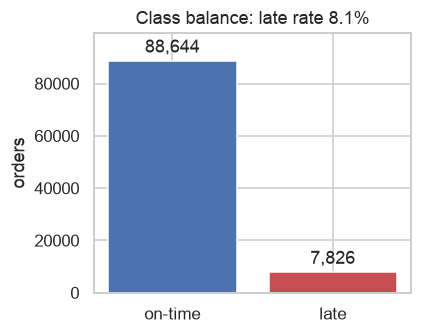

In [4]:
target_labels = {0: "on-time", 1: "late"}
counts = eda_df[TARGET_COLUMN].value_counts().reindex([0, 1], fill_value=0)
late_rate = counts.loc[1] / counts.sum()

print(counts.rename(target_labels))
print(f"\nlate rate: {late_rate:.1%}  (overall delivered-order baseline)")

fig, ax = plt.subplots(figsize=(4, 3.2))
labels = [target_labels[value] for value in counts.index]
bars = ax.bar(labels, counts.values, color=["#4c72b0", "#c44e52"])

ax.set_ylabel("orders")
ax.set_title(f"Class balance: late rate {late_rate:.1%}")
ax.bar_label(bars, labels=[f"{value:,}" for value in counts.values], padding=3)
ax.set_ylim(0, counts.max() * 1.12)
plt.tight_layout()
plt.show()

> **Insight — late deliveries are uncommon, so accuracy can be misleading.** Only **7,826 of 96,470** delivered orders are late (**8.1%**). If a model simply predicted "on-time" for every order, it would still be **91.9% accurate**, but it would catch **zero** late deliveries. That would not help the business identify shipments that need attention.
>
> So instead of judging the model mainly by accuracy, we use metrics that check whether it can put higher-risk orders near the top of the list:
>
> - **ROC-AUC** asks: if we compare one late order and one on-time order, does the model usually give the late order the higher risk score?
> - **PR-AUC** asks: among the orders the model flags as risky, how many are actually late, and how many late orders does it find? A no-skill PR-AUC equals the positive rate on the sample being evaluated. The overall delivered-order late rate is **8.1%**, but final model PR-AUC is evaluated on the chronological test slice, so its no-skill floor is the **test** late rate shown in the split/results tables (**5.3%**, or about **0.053**).
> - **Brier score** checks whether the predicted probabilities are believable. For example, among orders scored as 20% late risk, roughly 20% should actually arrive late.
>
> This also motivates class-imbalance weighting in the models — `class_weight="balanced"` for the logistic, LightGBM, and HistGradientBoosting models, and `scale_pos_weight` (the train-fold negative-to-positive ratio) for XGBoost — and choosing a business-driven alert threshold instead of automatically using 0.5.

## 2. Missingness & summary statistics

Missing values come mostly from left joins (a product/seller/zip not found) and from products with blank physical attributes. All benchmark pipelines impute before fitting: `make_preprocessor` applies a median `SimpleImputer` to numeric columns and a most-frequent `SimpleImputer` to categoricals, for both the logistic and tree models. Worth knowing which columns carry gaps before trusting their distributions.

In [5]:
miss = eda_df[EDA_NUMERIC_FEATURES + EDA_CATEGORICAL_FEATURES].isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    display(miss.to_frame("missing_fraction").style.format("{:.2%}"))
else:
    print("No missing values in feature columns.")

,missing_fraction
primary_product_category,1.38%
product_description_length_avg,1.38%
product_photos_qty_avg,1.38%
geo_distance_km,0.50%
payment_type,0.00%
payment_value_total,0.00%
payment_installments_max,0.00%


In [6]:
eda_df[EDA_NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
estimated_delivery_days,"96,470.000",23.736,8.761,2.008,18.330,23.231,28.408,155.135
shipping_limit_days,"96,470.000",6.575,4.661,2.004,5.006,6.012,7.136,"1,052.005"
shipping_limit_days_min,"96,470.000",6.561,4.656,2.004,5.006,6.012,7.118,"1,052.005"
shipping_limit_days_range,"96,470.000",0.014,0.321,0.000,0.000,0.000,0.000,25.000
n_unique_shipping_limits,"96,470.000",1.004,0.062,1.000,1.000,1.000,1.000,3.000
purchase_month,"96,470.000",6.031,3.228,1.000,3.000,6.000,8.000,12.000
purchase_dayofweek,"96,470.000",2.756,1.967,0.000,1.000,3.000,4.000,6.000
purchase_hour,"96,470.000",14.773,5.328,0.000,11.000,15.000,19.000,23.000
n_items,"96,470.000",1.142,0.539,1.000,1.000,1.000,1.000,21.000
n_distinct_products,"96,470.000",1.039,0.228,1.000,1.000,1.000,1.000,8.000


## 3. Numeric feature distributions

Many of these are heavy-tailed (price, freight, weight, volume, distance) — useful to know for the linear model, which benefits from the standardization already in its pipeline (and would benefit further from log transforms). For readability we **clip the values** at each feature's 99th percentile before plotting, so the top 1% of observations pile into the rightmost bin (this is a data clip, not just a cropped view — expect a small spike at the top edge).

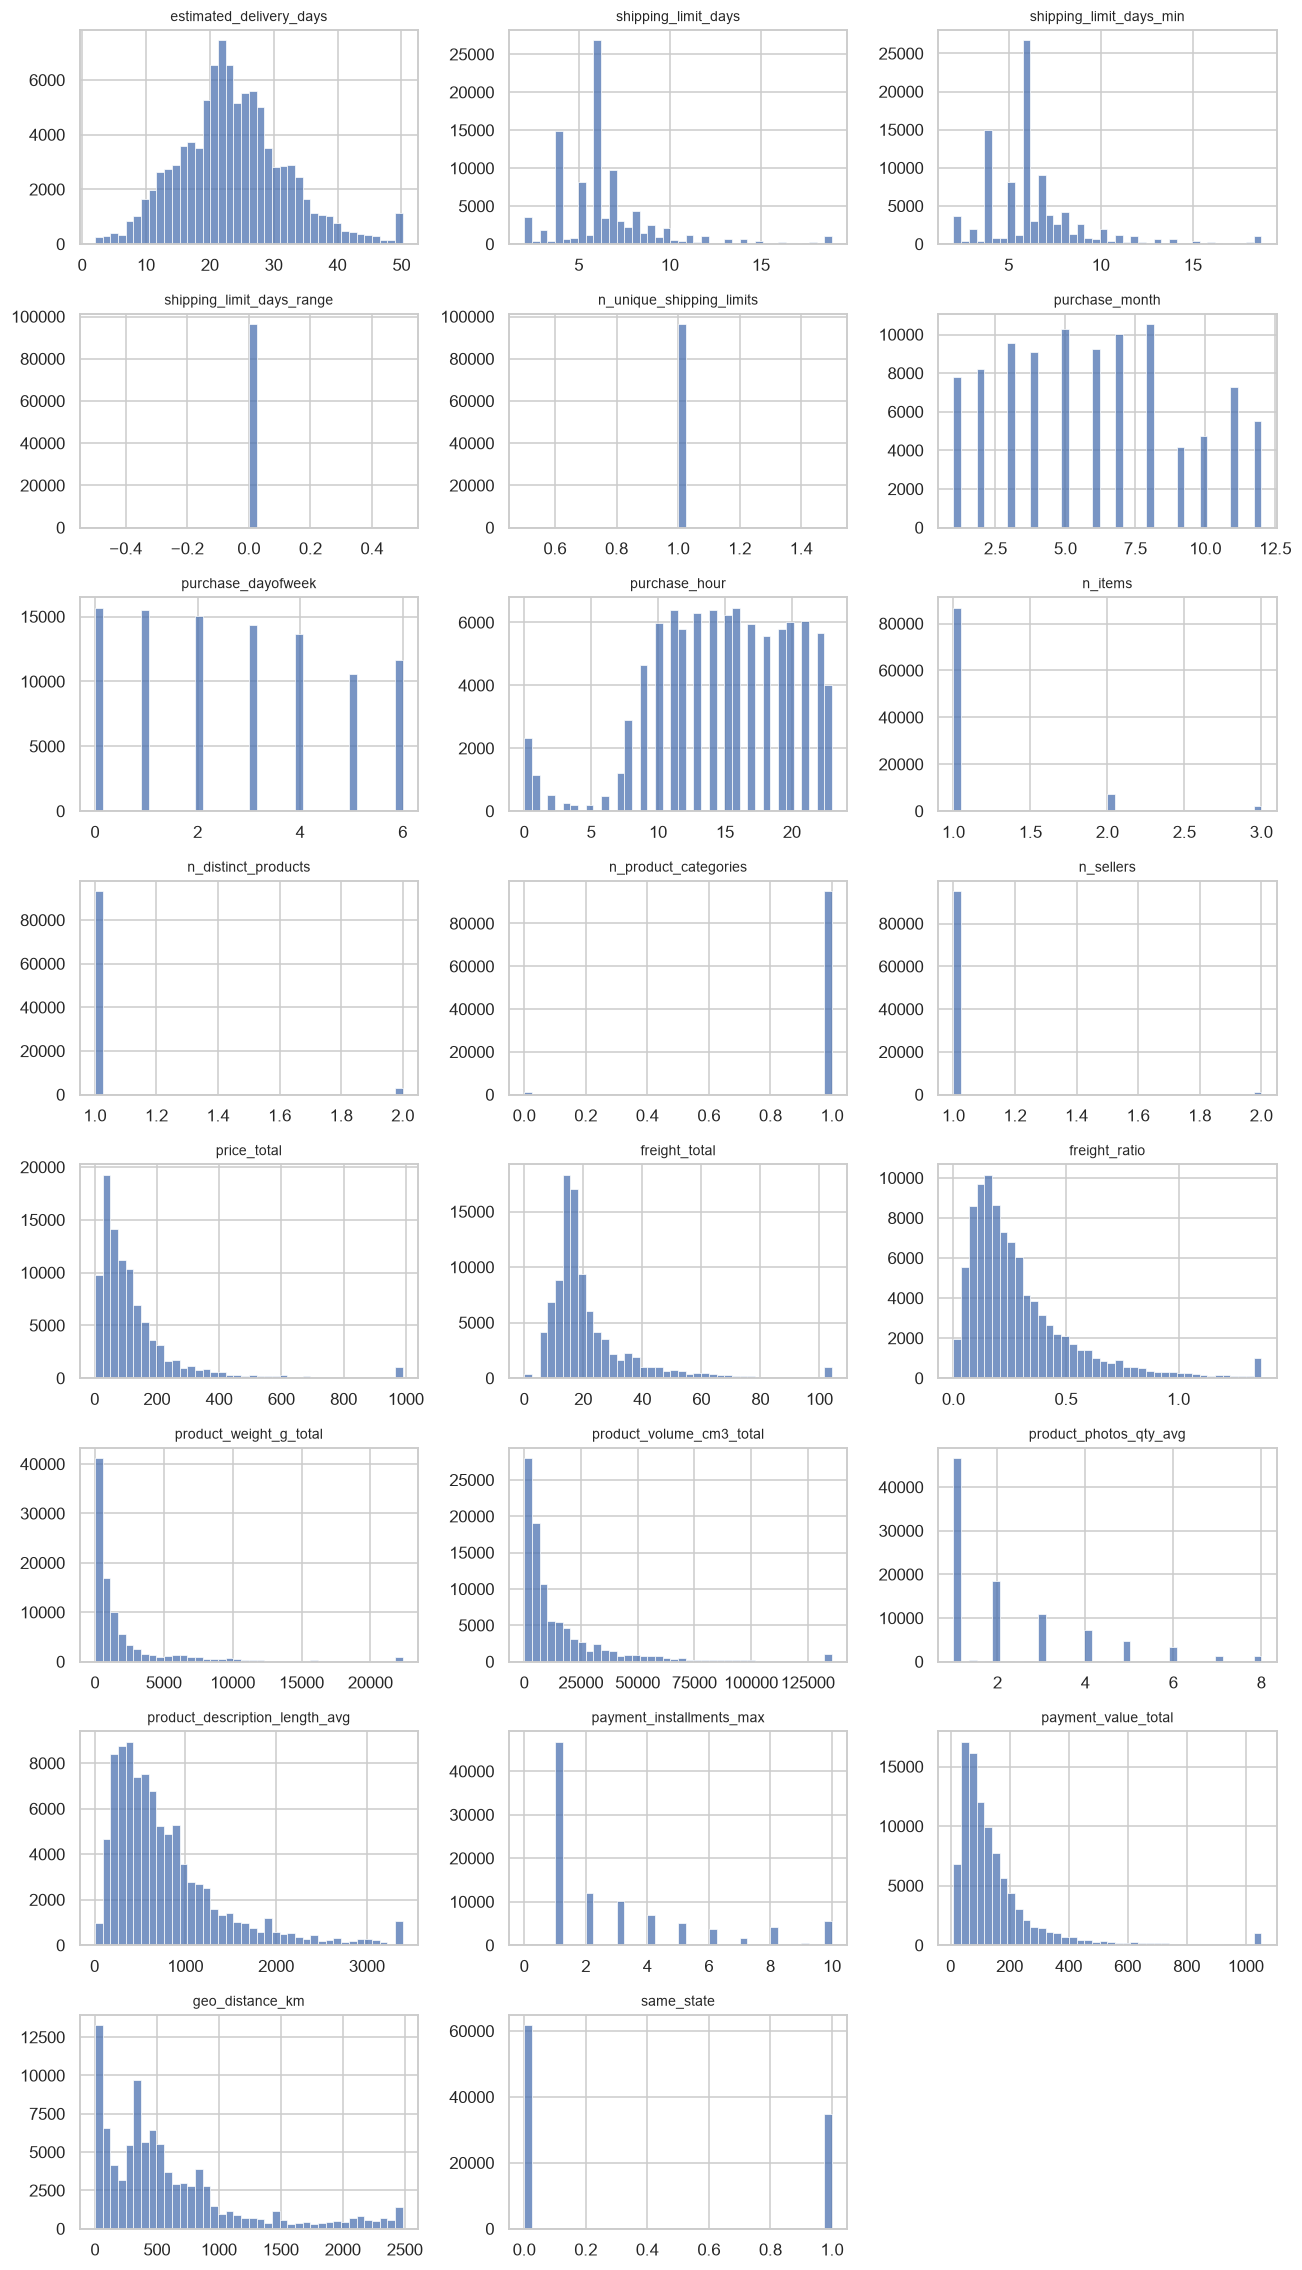

In [7]:
cols = EDA_NUMERIC_FEATURES
n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows))
for ax, col in zip(axes.ravel(), cols):
    s = eda_df[col].dropna()
    hi = s.quantile(0.99)
    sns.histplot(s.clip(upper=hi), bins=40, ax=ax, color="#4c72b0")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 4. Which features separate late from on-time?

The most informative univariate view for a rare-event problem: bin each numeric feature into deciles and plot the **late rate per bin**. A flat line means no signal; a strong slope means the feature ranks risk well on its own. We expect `estimated_delivery_days` (the promised window) and `geo_distance_km` to show the clearest slopes — though, as the next section quantifies, every univariate effect here is weak. Note the *directions* differ: a longer promised window should trend toward a **lower** late rate (more buffer, so the slope points down), whereas a longer distance should trend toward a higher one.

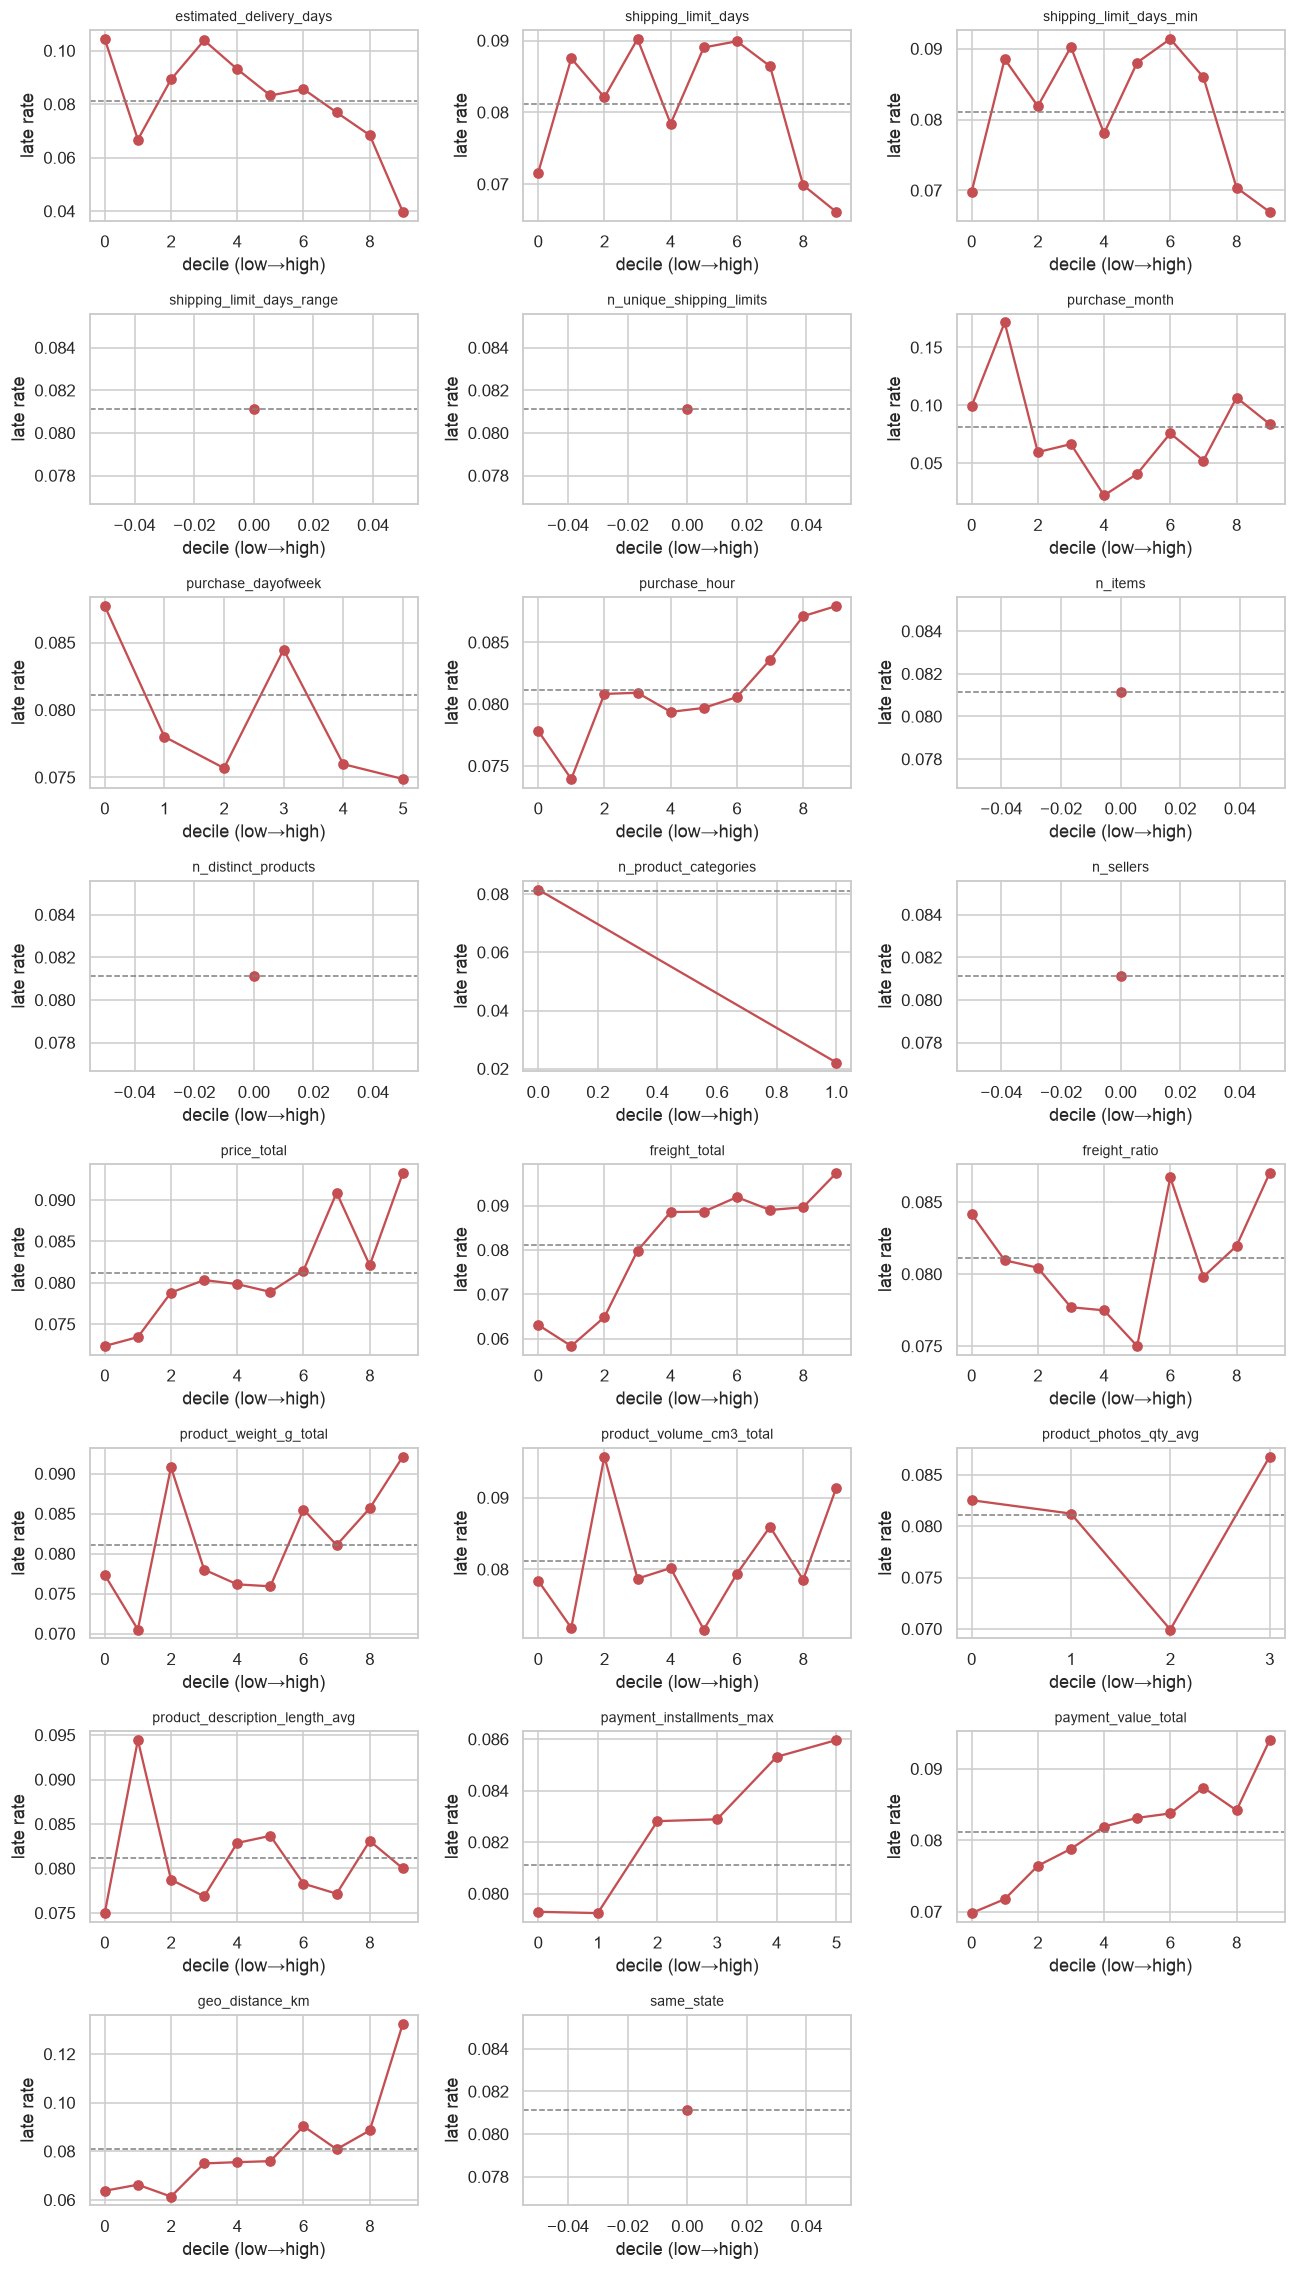

In [8]:
base = eda_df[TARGET_COLUMN].mean()
cols = EDA_NUMERIC_FEATURES
n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows))
for ax, col in zip(axes.ravel(), cols):
    tmp = eda_df[[col, TARGET_COLUMN]].dropna()
    try:
        tmp["bin"] = pd.qcut(tmp[col], q=10, duplicates="drop")
    except ValueError:
        ax.set_visible(False)
        continue
    rate = tmp.groupby("bin", observed=True)[TARGET_COLUMN].mean()
    ax.plot(range(len(rate)), rate.values, marker="o", color="#c44e52")
    ax.axhline(base, ls="--", color="gray", lw=1)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("decile (low→high)")
    ax.set_ylabel("late rate")
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 5. Correlation with the target (point-biserial) & feature–feature redundancy

A quick ranked view of each numeric feature's linear correlation with `late`, plus a heatmap to spot redundant features (e.g. weight vs. volume, price vs. payment value) that a linear model would double-count.

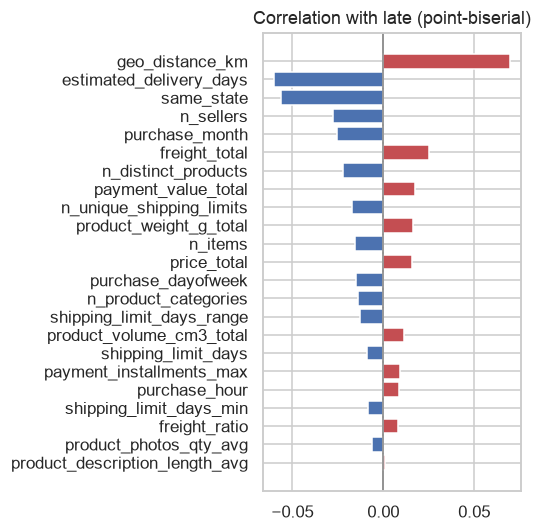

,corr_with_late
geo_distance_km,0.070
estimated_delivery_days,-0.060
same_state,-0.056
n_sellers,-0.028
purchase_month,-0.025
freight_total,0.025
n_distinct_products,-0.022
payment_value_total,0.017
n_unique_shipping_limits,-0.017
product_weight_g_total,0.017


In [9]:
corr_t = (
    eda_df[EDA_NUMERIC_FEATURES + [TARGET_COLUMN]]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=np.abs, ascending=False)
)
fig, ax = plt.subplots(figsize=(5, 5))
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in corr_t.values]
ax.barh(corr_t.index[::-1], corr_t.values[::-1], color=colors[::-1])
ax.axvline(0, color="gray", lw=1)
ax.set_title("Correlation with late (point-biserial)")
plt.tight_layout()
plt.show()
corr_t.to_frame("corr_with_late")

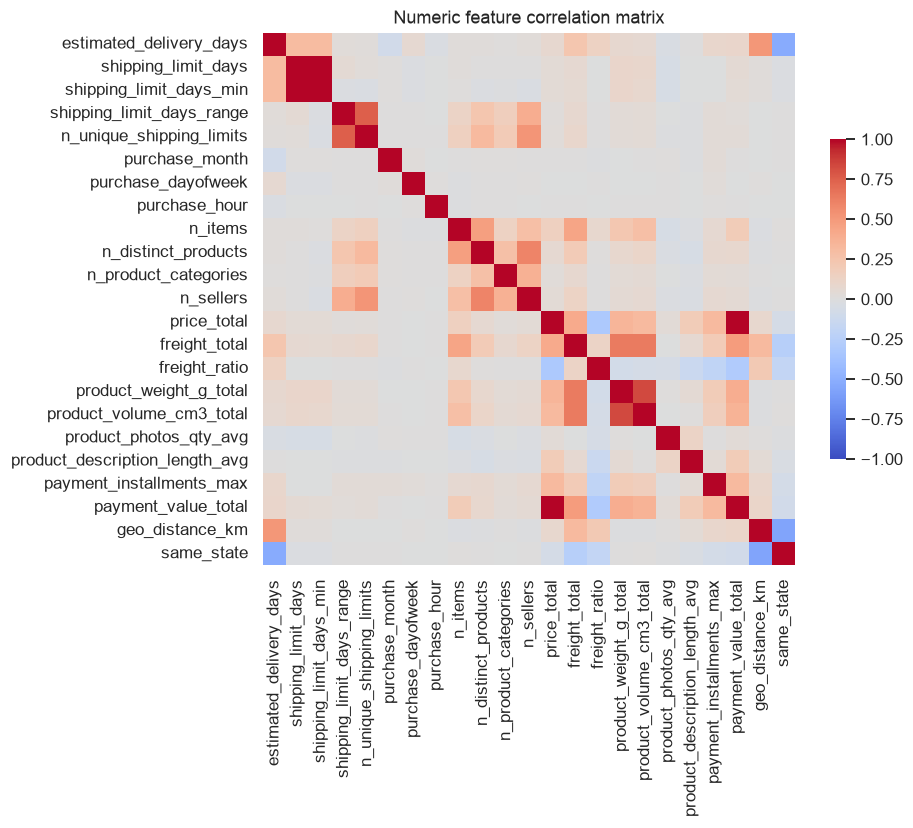

In [10]:
corr = eda_df[EDA_NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Numeric feature correlation matrix")
plt.tight_layout()
plt.show()

> **Insight — the signals are weak, and order-complexity features point the "wrong" way.** No single feature separates late from on-time on its own: every point-biserial correlation with `late` is small (|r| ≤ 0.07). The strongest few are at least intuitive — longer `geo_distance_km` (+0.07) and tighter `estimated_delivery_days` (−0.06, i.e. shorter promised windows) go with more late deliveries, and `same_state` orders (−0.06) are less late.
>
> The **unexpected** result is that the *order-complexity* features correlate **negatively** with lateness — `n_sellers` (−0.03), `n_distinct_products` (−0.02), and `n_items` (−0.02) — the opposite of the feature-rationale table, where larger, multi-seller baskets were expected to be *harder* to fulfill and therefore more late-prone. The most likely explanation is confounding: bigger or multi-seller orders may be granted more generous estimated windows or ship from better-resourced sellers, which offsets the added complexity. Either way, these weak and sometimes counterintuitive univariate effects are exactly why the modeling leans on multivariate, non-linear models instead of trusting any one column.

## 6. Categorical feature signal

Categorical fields can carry useful logistics signal, but several are high-cardinality (`customer_city`, `seller_city`, product category). To keep the view stable, this section only compares categories with at least 100 orders and shows the highest-risk values by late rate. The `lift_vs_base` column is the category late rate divided by the overall late rate.

,feature,category,orders,late_rate,lift_vs_base
88,customer_city,maceio,236,29.7%,3.66x
134,customer_city,sao goncalo,385,24.9%,3.07x
42,customer_city,cabo frio,113,23.9%,2.95x
141,customer_city,sao luis,335,22.4%,2.76x
151,customer_city,teresina,271,22.1%,2.73x
135,customer_city,sao joao de meriti,124,21.8%,2.68x
72,customer_city,hortolandia,142,21.1%,2.60x
100,customer_city,nova friburgo,142,21.1%,2.60x
0,customer_state,AL,397,23.9%,2.95x
7,customer_state,MA,717,19.7%,2.42x


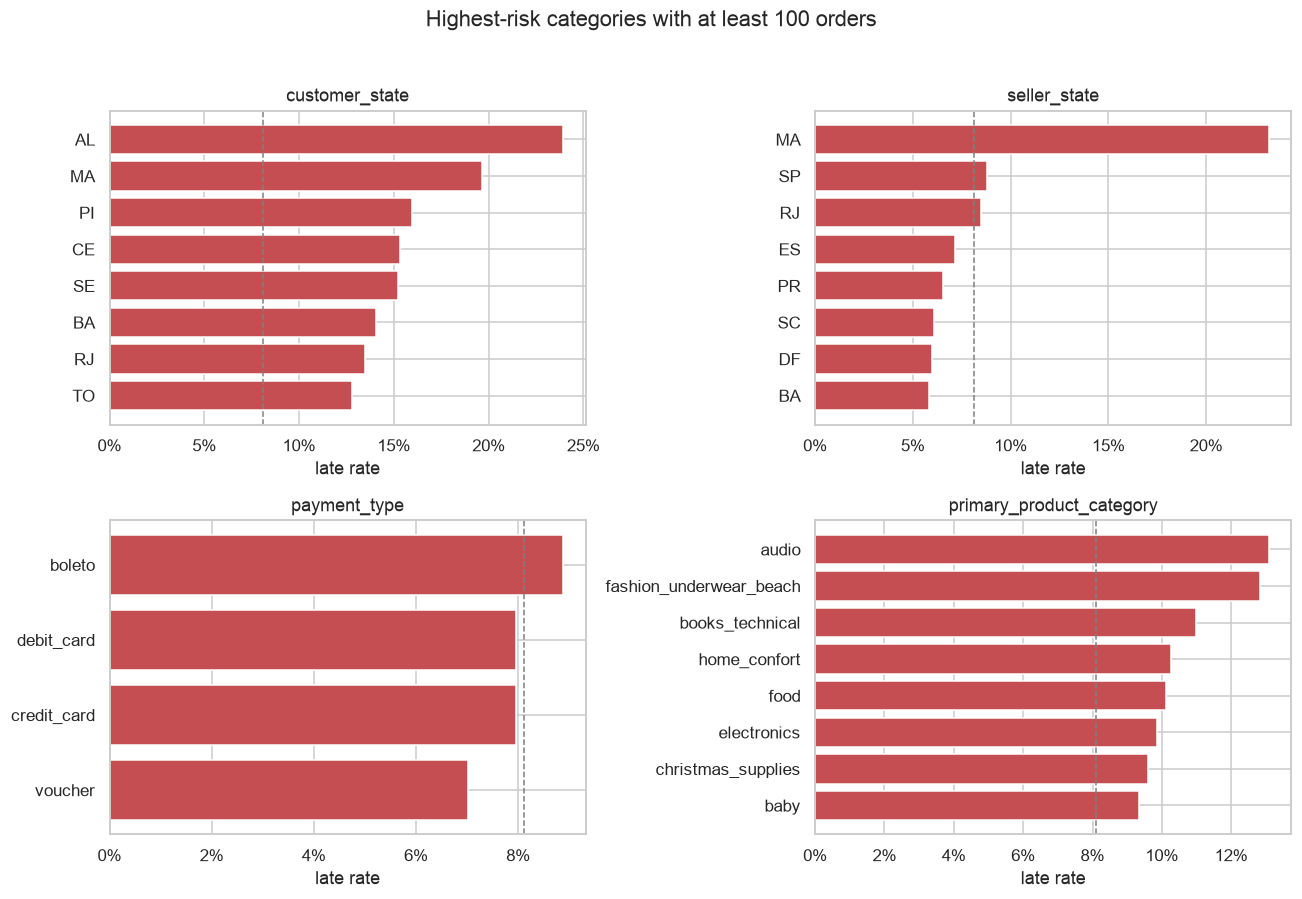

In [11]:
MIN_CATEGORY_ORDERS = 100
TOP_N_CATEGORIES = 8
base_late_rate = eda_df[TARGET_COLUMN].mean()

categorical_summaries = []
for feature in EDA_CATEGORICAL_FEATURES:
    summary = (
        eda_df.groupby(feature, dropna=False)[TARGET_COLUMN]
        .agg(orders="size", late_rate="mean")
        .reset_index()
    )
    summary = summary[summary["orders"] >= MIN_CATEGORY_ORDERS].copy()
    summary["feature"] = feature
    summary["lift_vs_base"] = summary["late_rate"] / base_late_rate
    summary = summary.rename(columns={feature: "category"})
    categorical_summaries.append(summary)

cat_signal = pd.concat(categorical_summaries, ignore_index=True)
cat_signal["category"] = cat_signal["category"].astype("string").fillna("missing")
cat_signal = cat_signal.sort_values(
    ["feature", "late_rate", "orders"], ascending=[True, False, False]
)

display(
    cat_signal.groupby("feature", group_keys=False)
    .head(TOP_N_CATEGORIES)
    .loc[:, ["feature", "category", "orders", "late_rate", "lift_vs_base"]]
    .style.format({"late_rate": "{:.1%}", "lift_vs_base": "{:.2f}x", "orders": "{:,.0f}"})
)

plot_features = [
    "customer_state",
    "seller_state",
    "payment_type",
    "primary_product_category",
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, feature in zip(axes, plot_features):
    top = (
        cat_signal[cat_signal["feature"] == feature]
        .nlargest(TOP_N_CATEGORIES, "late_rate")
        .sort_values("late_rate")
    )
    ax.barh(top["category"], top["late_rate"], color="#c44e52")
    ax.axvline(base_late_rate, color="gray", linestyle="--", linewidth=1)
    ax.set_title(feature)
    ax.set_xlabel("late rate")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle(f"Highest-risk categories with at least {MIN_CATEGORY_ORDERS:,} orders", y=1.02)
plt.tight_layout()
plt.show()

## 7. Is the signal stable over time?

Because we evaluate with a **chronological** train/test split, a large drift in the late rate between the early (train) and recent (test) periods would hurt any model. Here we plot the monthly late rate and order volume to check for regime shifts (e.g. the late-2017 demand spike).

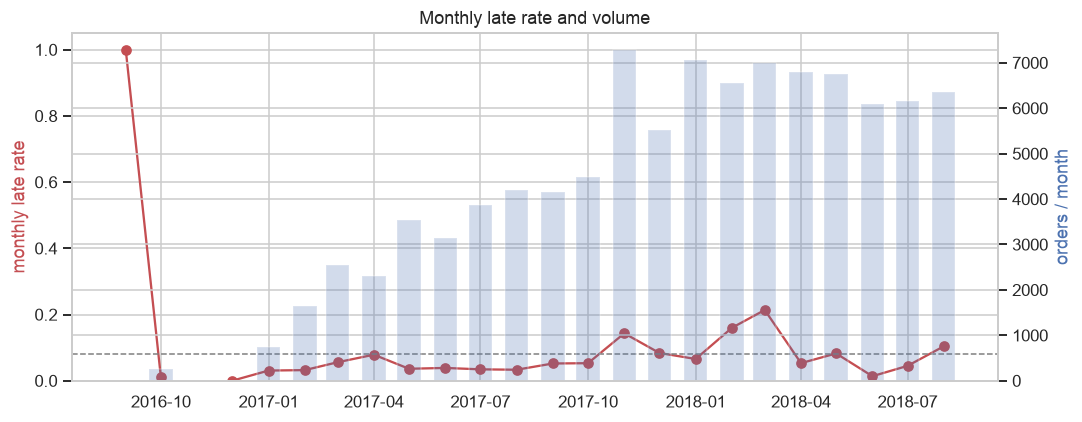

In [12]:
monthly = (
    eda_df.set_index(TIME_COLUMN)
    .resample("MS")[TARGET_COLUMN]
    .agg(["mean", "count"])
)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly.index, monthly["mean"], marker="o", color="#c44e52", label="late rate")
ax1.axhline(eda_df[TARGET_COLUMN].mean(), ls="--", color="gray", lw=1)
ax1.set_ylabel("monthly late rate", color="#c44e52")
ax1.set_ylim(0, None)
ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly["count"], width=20, alpha=0.25, color="#4c72b0")
ax2.set_ylabel("orders / month", color="#4c72b0")
ax1.set_title("Monthly late rate and volume")
plt.tight_layout()
plt.show()

## Notes
- **Primary-seller geography caveat:** `geo_distance_km`, `same_state`, `seller_state`, and `seller_city` are computed from the first line item's seller (`primary_seller_id`). For the small share of multi-seller orders (`n_sellers > 1`), these fields describe one origin rather than every seller in the order; all sellers exist in the raw item data, but this notebook collapses geography to a single primary seller for order-level modeling.


## Load Leakage-Safe Modeling Table

The EDA above explored a broad candidate set; the models below use the curated, leakage-safe subset defined in `src.features` (some high-cardinality or redundant candidates are intentionally dropped).

The feature table comes from `src.features.build_delivery_dataset` through `load_delivery_dataset`. It keeps only features known at checkout and excludes post-purchase timestamps such as carrier delivery and customer delivery dates.

In [13]:
df = load_delivery_dataset(DATA_DIR)  # src/data_loader.py::load_delivery_dataset

summary = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "late_rate": df[TARGET_COLUMN].mean(),
        "on_time_to_late_ratio": (1 - df[TARGET_COLUMN].mean()) / df[TARGET_COLUMN].mean(),
        "start_date": df[TIME_COLUMN].min().date(),
        "end_date": df[TIME_COLUMN].max().date(),
    }
)
summary

rows                          96470
columns                          26
late_rate                     0.081
on_time_to_late_ratio        11.327
start_date               2016-09-15
end_date                 2018-08-29
dtype: object

In [14]:
df[[TIME_COLUMN, TARGET_COLUMN, *FEATURE_COLUMNS]].describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,96470,2018-01-01 23:17:43.624412,2016-09-15 12:16:38,2017-09-14 08:56:46.500000,2018-01-20 19:34:43.500000,2018-05-05 18:29:50.250000,2018-08-29 15:00:37,NaN
late,"96,470.000",0.081,0.000,0.000,0.000,0.000,1.000,0.273
estimated_delivery_days,"96,470.000",23.736,2.008,18.330,23.231,28.408,155.135,8.761
shipping_limit_days,"96,470.000",6.575,2.004,5.006,6.012,7.136,"1,052.005",4.661
purchase_month,"96,470.000",6.031,1.000,3.000,6.000,8.000,12.000,3.228
purchase_dayofweek,"96,470.000",2.756,0.000,1.000,3.000,4.000,6.000,1.967
purchase_hour,"96,470.000",14.773,0.000,11.000,15.000,19.000,23.000,5.328
n_items,"96,470.000",1.142,1.000,1.000,1.000,1.000,21.000,0.539
n_distinct_products,"96,470.000",1.039,1.000,1.000,1.000,1.000,8.000,0.228
n_sellers,"96,470.000",1.014,1.000,1.000,1.000,1.000,5.000,0.124


## Chronological Train / Validation / Test Split

The split follows the production shape: train on older orders and evaluate on future orders. The validation slice is used only to choose the F1 operating threshold; final PR AUC, F1, Brier score, and calibration curves are reported on the most recent test slice.

In [15]:
def chronological_three_way_split(
    dataset: pd.DataFrame,
    valid_frac: float = 0.2,
    test_frac: float = 0.2,
    time_column: str = TIME_COLUMN,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    ordered = dataset.sort_values(time_column).reset_index(drop=True)
    test_start = int(len(ordered) * (1 - test_frac))
    valid_start = int(test_start * (1 - valid_frac))
    return (
        ordered.iloc[:valid_start].copy(),
        ordered.iloc[valid_start:test_start].copy(),
        ordered.iloc[test_start:].copy(),
    )


train, valid, test = chronological_three_way_split(df)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train), len(valid), len(test)],
        "late_rate": [train[TARGET_COLUMN].mean(), valid[TARGET_COLUMN].mean(), test[TARGET_COLUMN].mean()],
        "start": [train[TIME_COLUMN].min(), valid[TIME_COLUMN].min(), test[TIME_COLUMN].min()],
        "end": [train[TIME_COLUMN].max(), valid[TIME_COLUMN].max(), test[TIME_COLUMN].max()],
    }
)
split_summary

,split,rows,late_rate,start,end
0,train,61740,0.090,2016-09-15 12:16:38,2018-03-20 09:15:24
1,validation,15436,0.081,2018-03-20 09:16:16,2018-05-26 18:16:57
2,test,19294,0.053,2018-05-26 18:18:03,2018-08-29 15:00:37


## Logistic Regression Categorical Guardrail

Weighted logistic regression is useful here because it gives an interpretable baseline through coefficients and odds ratios. This interpretability depends on keeping the design matrix reasonably small: one-hot encoding too many categorical columns or high-cardinality levels can make the logistic model noisy, slow, and hard to explain.

This guardrail is applied **only to the weighted logistic regression model**. If the categorical feature set gets too wide, the notebook ranks categorical columns by their association with the target using **Cramer's V** (a categorical analogue to correlation). Lower-association categorical columns are dropped first until the logistic one-hot budget is back under the configured limit. The budget is measured against the number of columns the encoder actually emits after `min_frequency` collapses rare levels (`encoded_width_train`), not raw cardinality (`n_unique_train`), so the limit reflects the true design-matrix width. With the current project features (`customer_state`, `seller_state`, `payment_type`), this usually does not trigger, but the check is here so the logistic baseline remains disciplined if more categoricals are added later.

The tree-based benchmark models are not constrained by this logistic interpretability budget, so they keep using the full configured categorical feature set unless a separate model-specific reason says otherwise.

In [16]:
MAX_LOGIT_DUMMY_COLUMNS = 80
MIN_CATEGORICAL_CRAMERS_V = 0.02
ONEHOT_MIN_FREQUENCY = 20  # shared with the OneHotEncoder in make_preprocessor


def encoded_width(feature: pd.Series, min_frequency: int = ONEHOT_MIN_FREQUENCY) -> int:
    """Number of one-hot columns ``OneHotEncoder(min_frequency=...)`` actually emits:
    one per level seen at least ``min_frequency`` times, plus one shared column if any
    rare levels get collapsed. This is the real design-matrix width, which is <= nunique."""
    counts = feature.value_counts(dropna=True)
    frequent = int((counts >= min_frequency).sum())
    has_infrequent = bool((counts < min_frequency).any())
    return frequent + int(has_infrequent)


def cramers_v(feature: pd.Series, target: pd.Series) -> float:
    table = pd.crosstab(feature.fillna("__missing__"), target)
    if min(table.shape) < 2:
        return 0.0

    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    rows, cols = table.shape
    denom = max(1, min(rows - 1, cols - 1))
    return float(np.sqrt(phi2 / denom))


def select_logistic_categoricals(
    dataset: pd.DataFrame,
    categorical_features: list[str],
    target: str = TARGET_COLUMN,
    max_dummy_columns: int = MAX_LOGIT_DUMMY_COLUMNS,
    min_cramers_v: float = MIN_CATEGORICAL_CRAMERS_V,
    min_frequency: int = ONEHOT_MIN_FREQUENCY,
) -> tuple[list[str], pd.DataFrame]:
    profile = pd.DataFrame(
        [
            {
                "feature": feature,
                "n_unique_train": dataset[feature].nunique(dropna=False),
                "encoded_width_train": encoded_width(dataset[feature], min_frequency),
                "cramers_v_to_target": cramers_v(dataset[feature], dataset[target]),
            }
            for feature in categorical_features
        ]
    ).sort_values("cramers_v_to_target", ascending=False)

    # Budget against the width the encoder actually emits (min_frequency collapses rare
    # levels), not raw cardinality. n_unique_train is kept only as an informational column.
    total_width = int(profile["encoded_width_train"].sum())
    if total_width <= max_dummy_columns:
        return categorical_features, profile.assign(selected=True, reason="within one-hot budget")

    selected: list[str] = []
    used_width = 0
    reasons: dict[str, str] = {}
    for row in profile.itertuples(index=False):
        enough_signal = row.cramers_v_to_target >= min_cramers_v
        fits_budget = used_width + row.encoded_width_train <= max_dummy_columns
        if enough_signal and (fits_budget or not selected):
            selected.append(row.feature)
            used_width += int(row.encoded_width_train)
            reasons[row.feature] = "kept: stronger target association"
        else:
            reasons[row.feature] = "dropped: lower association or budget pressure"

    return selected, profile.assign(
        selected=profile["feature"].isin(selected),
        reason=profile["feature"].map(reasons),
    )


logistic_categorical_features, categorical_profile = select_logistic_categoricals(train, CATEGORICAL_FEATURES)
logistic_feature_columns = NUMERIC_FEATURES + logistic_categorical_features

print("Logistic categorical features:", logistic_categorical_features)
categorical_profile

Logistic categorical features: ['customer_state', 'seller_state', 'payment_type']


,feature,n_unique_train,encoded_width_train,cramers_v_to_target,selected,reason
0,customer_state,27,27,0.156,True,within one-hot budget
1,seller_state,22,17,0.055,True,within one-hot budget
2,payment_type,5,4,0.017,True,within one-hot budget


### Categorical Features Used by Each Model

`CATEGORICAL_FEATURES` (defined in `src.features`) is the full set of categorical columns the models draw from: `customer_state`, `seller_state`, and `payment_type`. These are the categoricals the **tree models (XGBoost, LightGBM, and HistGradientBoosting) use in full** — boosted trees split on one-hot columns without an interpretability penalty, so there is no reason to prune them.

The **weighted logistic regression** instead uses only the guardrail-**selected** subset (`logistic_categorical_features`). The guardrail keeps the logistic design matrix small enough to stay interpretable: it ranks the categoricals by **Cramer's V** (association with the target) and drops the weakest ones only if the total one-hot width would exceed `MAX_LOGIT_DUMMY_COLUMNS`. With today's three low-cardinality features the budget is not exceeded, so all three are selected and the logistic and tree models happen to use the same set.

The table below lists every feature in `CATEGORICAL_FEATURES` **plus the high-cardinality categoricals that were excluded before modeling** (`customer_city`, `seller_city`, `product_category_name`), each with its cardinality, target association (`cramers_v_to_target`), and which models use it. The excluded columns are not in the modeling table, so their Cramer's V is computed from a rebuilt order-level table using the same delivered-order filter and the same chronological training cutoff. The cell below checks this by also carrying `customer_state` (which exists in both tables) through the rebuild and confirming its Cramer's V matches the guardrail value.

**Caveat on Cramer's V and cardinality.** Cramer's V is biased upward for high-cardinality features: more levels mechanically inflate it even without more real signal. Notice `customer_city` scores *higher* than `customer_state` purely because it has thousands of levels. That inflated score is **not** a reason to include it — one-hot encoding thousands of sparse city levels would explode the design matrix, overfit, and destroy interpretability, and the location signal is already captured densely via `geo_distance_km` and `same_state`. So the exclusion is deliberate, not an oversight.

In [17]:
from src.data_loader import load_raw_tables


def _extended_categorical_train_table() -> pd.DataFrame:
    """Rebuild an order-level train table that also carries the high-cardinality
    categoricals excluded from the modeling table, so their association with the
    target can be measured on the same delivered orders and chronological cutoff."""
    raw = load_raw_tables(DATA_DIR)  # src/data_loader.py::load_raw_tables
    orders = raw.orders.copy()
    for col in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
        orders[col] = pd.to_datetime(orders[col])
    delivered = orders[orders["order_status"] == "delivered"].dropna(
        subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
    )
    base = delivered[
        ["order_id", "customer_id", "order_purchase_timestamp",
         "order_delivered_customer_date", "order_estimated_delivery_date"]
    ].copy()
    base[TARGET_COLUMN] = (
        base["order_delivered_customer_date"] > base["order_estimated_delivery_date"]
    ).astype(int)

    primary = (
        raw.order_items.sort_values("order_item_id")
        .groupby("order_id")
        .agg(product_id=("product_id", "first"), primary_seller_id=("seller_id", "first"))
    )
    base = (
        base.merge(primary, on="order_id", how="left")
        .merge(raw.products[["product_id", "product_category_name"]], on="product_id", how="left")
        .merge(raw.customers[["customer_id", "customer_city", "customer_state"]], on="customer_id", how="left")
        .merge(
            raw.sellers[["seller_id", "seller_city"]].rename(columns={"seller_id": "primary_seller_id"}),
            on="primary_seller_id",
            how="left",
        )
    )
    base = base.sort_values("order_purchase_timestamp").reset_index(drop=True)
    test_start = int(len(base) * 0.8)
    valid_start = int(test_start * 0.8)
    return base.iloc[:valid_start]


extended_train = _extended_categorical_train_table()

# Sanity check that the rebuilt table reproduces the guardrail's training population:
# customer_state exists in BOTH tables, so its Cramer's V must line up with the value
# computed on the modeling train fold in `categorical_profile`.
guardrail_state_v = float(
    categorical_profile.set_index("feature").loc["customer_state", "cramers_v_to_target"]
)
rebuilt_state_v = cramers_v(extended_train["customer_state"], extended_train[TARGET_COLUMN])
print(
    "customer_state Cramer's V — "
    f"guardrail: {guardrail_state_v:.4f} | rebuilt table: {rebuilt_state_v:.4f} | "
    f"match: {np.isclose(guardrail_state_v, rebuilt_state_v, atol=1e-3)}"
)

# Categoricals that exist at purchase time but are dropped before modeling (too high-cardinality).
EXCLUDED_CATEGORICALS = {"customer_city": "city", "seller_city": "city", "product_category_name": "category"}
GRANULARITY = {"customer_state": "state", "seller_state": "state", "payment_type": "type"}

usage_records = []
for row in categorical_profile.itertuples(index=False):
    usage_records.append(
        {
            "feature": row.feature,
            "granularity": GRANULARITY.get(row.feature, "other"),
            "n_unique_train": int(row.n_unique_train),
            "cramers_v_to_target": row.cramers_v_to_target,
            "used_by_tree_models": True,
            "used_by_logistic": row.feature in logistic_categorical_features,
        }
    )
for feature, granularity in EXCLUDED_CATEGORICALS.items():
    usage_records.append(
        {
            "feature": feature,
            "granularity": granularity,
            "n_unique_train": int(extended_train[feature].nunique(dropna=False)),
            "cramers_v_to_target": cramers_v(extended_train[feature], extended_train[TARGET_COLUMN]),
            "used_by_tree_models": False,
            "used_by_logistic": False,
        }
    )

categorical_usage = pd.DataFrame(usage_records)
categorical_usage["reason"] = np.select(
    [categorical_usage["used_by_logistic"], categorical_usage["used_by_tree_models"]],
    [
        "used by all models (fits logistic one-hot budget)",
        "tree models only (pruned from logistic by Cramer's V / one-hot budget)",
    ],
    default="excluded before modeling (high cardinality; geo signal kept via geo_distance_km / same_state)",
)
categorical_usage = categorical_usage.sort_values(
    ["used_by_tree_models", "cramers_v_to_target"], ascending=[False, False]
).reset_index(drop=True)

print("Full CATEGORICAL_FEATURES (used by tree models):", CATEGORICAL_FEATURES)
print("Selected for logistic regression:", logistic_categorical_features)
categorical_usage

customer_state Cramer's V — guardrail: 0.1559 | rebuilt table: 0.1559 | match: True
Full CATEGORICAL_FEATURES (used by tree models): ['customer_state', 'seller_state', 'payment_type']
Selected for logistic regression: ['customer_state', 'seller_state', 'payment_type']


,feature,granularity,n_unique_train,cramers_v_to_target,used_by_tree_models,used_by_logistic,reason
0,customer_state,state,27,0.156,True,True,used by all models (fits logistic one-hot budget)
1,seller_state,state,22,0.055,True,True,used by all models (fits logistic one-hot budget)
2,payment_type,type,5,0.017,True,True,used by all models (fits logistic one-hot budget)
3,customer_city,city,3653,0.305,False,False,excluded before modeling (high cardinality; ge...
4,seller_city,city,467,0.138,False,False,excluded before modeling (high cardinality; ge...
5,product_category_name,category,73,0.056,False,False,excluded before modeling (high cardinality; ge...


## Model Definitions

All models use the same leakage-safe feature table. The logistic model scales numeric features and one-hot encodes only the categorical features selected by the logistic guardrail above. The tree models (XGBoost, LightGBM, and HistGradientBoosting) use the full configured categorical feature set (`CATEGORICAL_FEATURES`) and do not need numeric scaling.

`scale_pos_weight` for XGBoost is set to the negative-to-positive ratio measured on the chronological train fold, so the class weighting always matches the data the model is actually fit on. That ratio is computed and printed below.

The **HistGradientBoosting** model reuses the exact estimator and hyperparameters promoted to `src.model.build_model_pipeline` (`learning_rate=0.1`, `max_iter=300`, `l2_regularization=1.0`, `class_weight="balanced"`), so the benchmark row for `04_hist_gradient_boosting` compares the shipped model against the other candidates. This row is a production-model baseline, not a claim that it wins the benchmark. It trains on the three-way split's train slice (about 64% of the data) and is scored on the held-out test slice, whereas `train_model_artifact` (cell 50) refits it on the larger train/test split (about 80%).

In [18]:
def make_preprocessor(categorical_features: list[str], *, scale_numeric: bool) -> ColumnTransformer:
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))

    numeric = Pipeline(steps=numeric_steps)
    categorical = Pipeline(
        steps=[
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=ONEHOT_MIN_FREQUENCY, sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric, NUMERIC_FEATURES),
            ("cat", categorical, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


observed_scale_pos_weight = (train[TARGET_COLUMN] == 0).sum() / (train[TARGET_COLUMN] == 1).sum()
print(f"Train negative-to-positive ratio (used as XGBoost scale_pos_weight): {observed_scale_pos_weight:.2f}")

models: dict[str, Pipeline] = {
    "01_weighted_logistic_regression": Pipeline(
        steps=[
            ("prep", make_preprocessor(logistic_categorical_features, scale_numeric=True)),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    solver="lbfgs",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
}

if XGBClassifier is not None:
    models["02_xgboost_scale_pos_weight"] = Pipeline(
        steps=[
            ("prep", make_preprocessor(CATEGORICAL_FEATURES, scale_numeric=False)),
            (
                "clf",
                XGBClassifier(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=4,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    eval_metric="logloss",
                    scale_pos_weight=observed_scale_pos_weight,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

if LGBMClassifier is not None:
    models["03_lightgbm_class_weight_balanced"] = Pipeline(
        steps=[
            ("prep", make_preprocessor(CATEGORICAL_FEATURES, scale_numeric=False)),
            (
                "clf",
                LGBMClassifier(
                    n_estimators=500,
                    learning_rate=0.05,
                    num_leaves=31,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                ),
            ),
        ]
    )

# Mirrors the production model in src/model.py (same estimator + hyperparameters),
# so the model that actually ships is benchmarked alongside the others.
models["04_hist_gradient_boosting"] = Pipeline(
    steps=[
        ("prep", make_preprocessor(CATEGORICAL_FEATURES, scale_numeric=False)),
        (
            "clf",
            HistGradientBoostingClassifier(
                learning_rate=0.1,
                max_iter=300,
                max_depth=None,
                l2_regularization=1.0,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

list(models)

Train negative-to-positive ratio (used as XGBoost scale_pos_weight): 10.12


['01_weighted_logistic_regression',
 '02_xgboost_scale_pos_weight',
 '03_lightgbm_class_weight_balanced',
 '04_hist_gradient_boosting']

## Fit and Evaluate

PR AUC is evaluated directly on test probabilities. F1 depends on a threshold, so the threshold is selected on the validation period and then applied once to the test period.

In [19]:
def best_f1_threshold(y_true: pd.Series, y_proba: np.ndarray) -> tuple[float, float]:  # promoted to src/evaluate.py::best_f1_threshold
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_values = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    # precision/recall include one extra point that has no corresponding threshold.
    best_idx = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_idx]), float(f1_values[best_idx])


def evaluate_model(model: Pipeline, threshold: float) -> dict[str, float]:
    test_proba = model.predict_proba(test[FEATURE_COLUMNS])[:, 1]
    test_pred = (test_proba >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(test[TARGET_COLUMN], test_proba),
        "f1": f1_score(test[TARGET_COLUMN], test_pred),
        "brier": brier_score_loss(test[TARGET_COLUMN], test_proba),
        "threshold_from_validation": threshold,
        "test_positive_rate": test[TARGET_COLUMN].mean(),
        "predicted_positive_rate": test_pred.mean(),
    }


fitted_models: dict[str, Pipeline] = {}
test_probabilities: dict[str, np.ndarray] = {}
rows = []

for name, model in models.items():
    print(f"Fitting {name} ...")
    model.fit(train[FEATURE_COLUMNS], train[TARGET_COLUMN])
    fitted_models[name] = model

    valid_proba = model.predict_proba(valid[FEATURE_COLUMNS])[:, 1]
    threshold, valid_f1 = best_f1_threshold(valid[TARGET_COLUMN], valid_proba)  # src/evaluate.py::best_f1_threshold

    metrics = evaluate_model(model, threshold)
    rows.append({"model": name, "validation_f1_at_threshold": valid_f1, **metrics})
    test_probabilities[name] = model.predict_proba(test[FEATURE_COLUMNS])[:, 1]

results = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
results

Fitting 01_weighted_logistic_regression ...


Fitting 02_xgboost_scale_pos_weight ...


Fitting 03_lightgbm_class_weight_balanced ...


Fitting 04_hist_gradient_boosting ...


,model,validation_f1_at_threshold,pr_auc,f1,brier,threshold_from_validation,test_positive_rate,predicted_positive_rate
0,02_xgboost_scale_pos_weight,0.262,0.139,0.021,0.101,0.740,0.053,0.002
1,03_lightgbm_class_weight_balanced,0.254,0.126,0.057,0.096,0.676,0.053,0.011
2,04_hist_gradient_boosting,0.261,0.118,0.059,0.125,0.668,0.053,0.018
3,01_weighted_logistic_regression,0.303,0.115,0.144,0.249,0.693,0.053,0.124


## Predictions for Both Classes

Each fitted model exposes probabilities for both classes: `P(on_time)` for class `0` and `P(late)` for class `1`. The table below also applies the validation-selected threshold to produce the final predicted class used for F1.

In [20]:
threshold_by_model = results.set_index("model")["threshold_from_validation"].to_dict()
prediction_frames: dict[str, pd.DataFrame] = {}

for name, model in fitted_models.items():
    proba = model.predict_proba(test[FEATURE_COLUMNS])
    predicted_late = (proba[:, 1] >= threshold_by_model[name]).astype(int)

    prediction_frames[name] = pd.DataFrame(
        {
            "model": name,
            "order_purchase_timestamp": test[TIME_COLUMN].to_numpy(),
            "actual_class": test[TARGET_COLUMN].to_numpy(),
            "actual_label": np.where(test[TARGET_COLUMN].to_numpy() == 1, "late", "on_time"),
            "proba_on_time_class_0": proba[:, 0],
            "proba_late_class_1": proba[:, 1],
            "predicted_class": predicted_late,
            "predicted_label": np.where(predicted_late == 1, "late", "on_time"),
            "threshold_from_validation": threshold_by_model[name],
        },
        index=test.index,
    )

predictions = pd.concat(prediction_frames.values()).reset_index(names="test_row_index")

prediction_summary = (
    predictions.groupby("model")["predicted_label"]
    .value_counts(normalize=False)
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
)

prediction_summary

predicted_label,late,on_time,total
model,,,
01_weighted_logistic_regression,2390,16904,19294
02_xgboost_scale_pos_weight,39,19255,19294
03_lightgbm_class_weight_balanced,207,19087,19294
04_hist_gradient_boosting,344,18950,19294


In [21]:
predictions.head(10)

,test_row_index,model,order_purchase_timestamp,actual_class,actual_label,proba_on_time_class_0,proba_late_class_1,predicted_class,predicted_label,threshold_from_validation
0,77176,01_weighted_logistic_regression,2018-05-26 18:18:03,0,on_time,0.717,0.283,0,on_time,0.693
1,77177,01_weighted_logistic_regression,2018-05-26 18:25:53,0,on_time,0.844,0.156,0,on_time,0.693
2,77178,01_weighted_logistic_regression,2018-05-26 18:41:31,0,on_time,0.828,0.172,0,on_time,0.693
3,77179,01_weighted_logistic_regression,2018-05-26 18:50:39,0,on_time,0.782,0.218,0,on_time,0.693
4,77180,01_weighted_logistic_regression,2018-05-26 18:51:09,0,on_time,0.803,0.197,0,on_time,0.693
5,77181,01_weighted_logistic_regression,2018-05-26 18:55:12,1,late,0.517,0.483,0,on_time,0.693
6,77182,01_weighted_logistic_regression,2018-05-26 19:08:23,0,on_time,0.740,0.260,0,on_time,0.693
7,77183,01_weighted_logistic_regression,2018-05-26 19:19:41,0,on_time,0.705,0.295,0,on_time,0.693
8,77184,01_weighted_logistic_regression,2018-05-26 19:20:39,0,on_time,0.744,0.256,0,on_time,0.693
9,77185,01_weighted_logistic_regression,2018-05-26 19:30:51,0,on_time,0.608,0.392,0,on_time,0.693


## Metric Comparison

Higher is better for PR AUC and F1. Lower is better for Brier score. Because the positive class is rare, PR AUC should be read relative to the test late rate shown above: the no-skill PR-AUC floor for these reported test scores is **0.053**, not the 0.081 overall dataset rate.

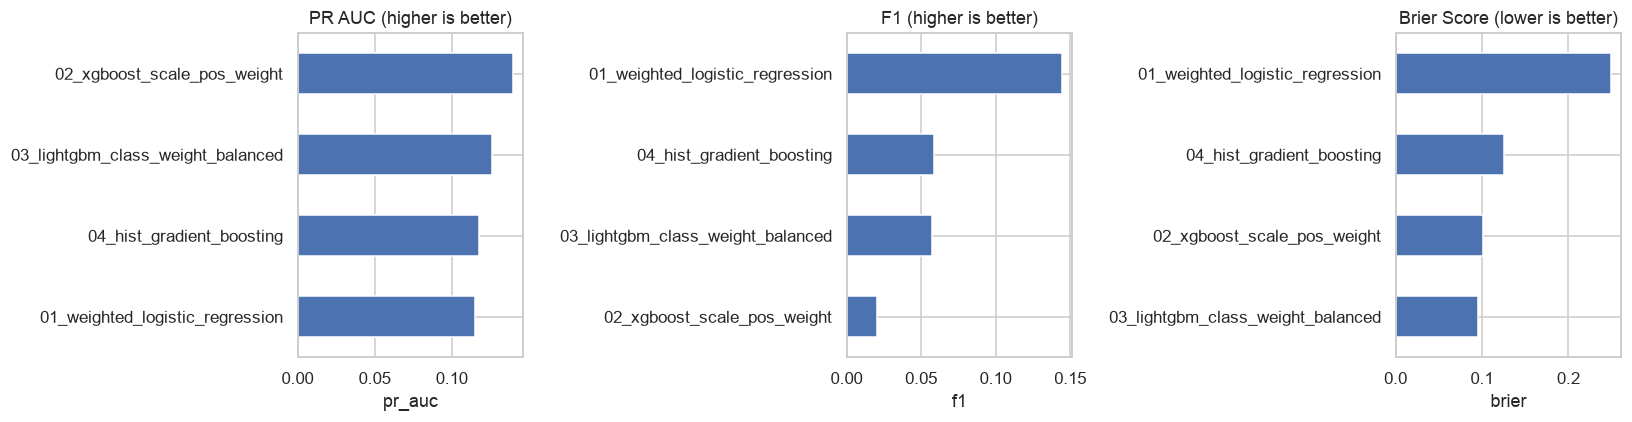

In [22]:
plot_results = results.set_index("model")[["pr_auc", "f1", "brier"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, metric, title in zip(
    axes,
    ["pr_auc", "f1", "brier"],
    ["PR AUC (higher is better)", "F1 (higher is better)", "Brier Score (lower is better)"],
):
    plot_results[metric].sort_values().plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("")

plt.tight_layout()

## Calibration Curves

Use these if the predicted probability itself matters, for example if operations will rank orders by expected risk or if thresholds will be tied to intervention costs. Class weighting often improves recall but can make probabilities overconfident, so the curve and Brier score should be checked before treating scores as calibrated probabilities.

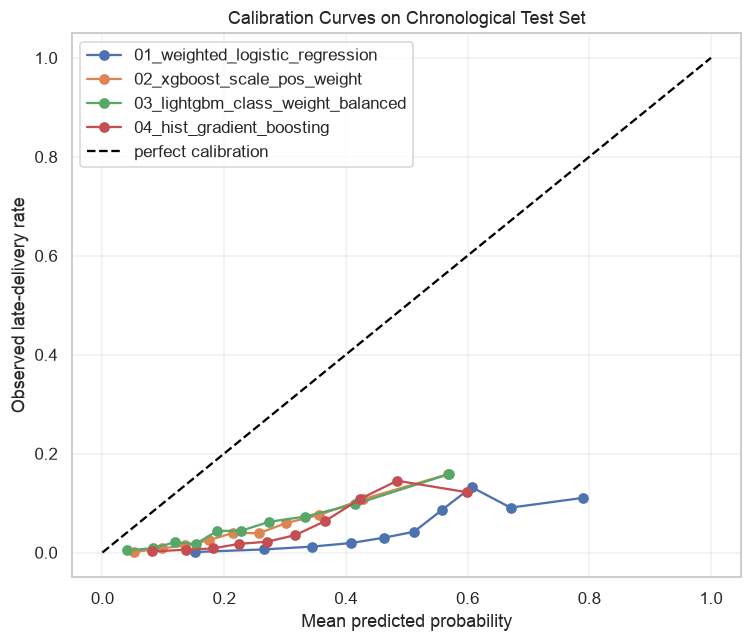

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in test_probabilities.items():
    frac_pos, mean_pred = calibration_curve(
        test[TARGET_COLUMN],
        proba,
        n_bins=10,
        strategy="quantile",
    )
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="perfect calibration")
ax.set_title("Calibration Curves on Chronological Test Set")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed late-delivery rate")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()

## Logistic Regression Interpretation

The coefficient table below is only for the weighted logistic regression baseline. Numeric coefficients are on standardized features; categorical coefficients are one-hot encoded levels. Positive coefficients increase late-delivery odds, while negative coefficients decrease them.

In [24]:
logit_name = "01_weighted_logistic_regression"
if logit_name in fitted_models:
    logit_model = fitted_models[logit_name]
    feature_names = logit_model.named_steps["prep"].get_feature_names_out()
    coefficients = logit_model.named_steps["clf"].coef_[0]

    coef_table = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "odds_ratio": np.exp(coefficients),
            "abs_coefficient": np.abs(coefficients),
        }
    ).sort_values("abs_coefficient", ascending=False)

    display(coef_table.head(20))

,feature,coefficient,odds_ratio,abs_coefficient
39,cat__customer_state_RO,-1.159,0.314,1.159
20,cat__customer_state_AL,1.028,2.797,1.028
19,cat__customer_state_AC,-0.937,0.392,0.937
55,cat__seller_state_PE,-0.800,0.449,0.800
47,cat__seller_state_CE,0.755,2.127,0.755
37,cat__customer_state_RJ,0.739,2.094,0.739
0,num__estimated_delivery_days,-0.736,0.479,0.736
54,cat__seller_state_MT,-0.718,0.488,0.718
53,cat__seller_state_MS,-0.583,0.558,0.583
61,cat__seller_state_SP,0.582,1.789,0.582


## Reading the Benchmark

- For pure late-order **ranking**, prefer the model with the strongest **test PR AUC**. In the displayed benchmark run, that is XGBoost.
- For an alerting workflow that needs a hard class decision, read **F1** together with the validation-selected threshold shown in `results`; changing the threshold changes F1. In the displayed run, logistic regression has the best test F1 at its validation-selected threshold.
- **Why production ships `HistGradientBoosting`, not the top-PR-AUC XGBoost.** XGBoost wins raw ranking (test PR AUC 0.139 vs HistGradientBoosting's 0.118), but the gap is small and both sit only modestly above the 0.053 test base rate. At its validation-selected threshold XGBoost's decisions collapse (test F1 0.021, only ~0.2% of orders flagged), so it is weak for the alerting workflow that needs a hard class decision, whereas HistGradientBoosting keeps a usable operating point (test F1 0.059). HistGradientBoosting also ships inside scikit-learn — no extra runtime dependency in `src/` — and handles NaNs natively. Production therefore trades a marginal ranking edge for a simpler, better-behaved decision model; the `04_hist_gradient_boosting` row and the smoke test below are a shipped-model comparison point, not the offline ranking winner. Revisit this choice if the XGBoost PR-AUC lead widens materially or the use case shifts to pure ranking.
- If the model output will be consumed as a probability, inspect **Brier score** and the calibration curve before trusting raw weighted-model probabilities.
- If calibration is poor but ranking is good, add a calibration step such as `CalibratedClassifierCV` on a later validation period before choosing an operating threshold.

## Production API (promoted to `src/`)

The evaluation helpers below are prototyped here and then promoted to
`src/evaluate.py`, so the CLI (`python -m src.main`) and the tests share the
same logic:

- `time_based_split`, `best_f1_threshold`, `evaluate_classifier` -> `src/evaluate.py`

Unlike the exploratory three-way split above, the production smoke test starts
with a simpler chronological **train/test** split. `train_model_artifact` then
uses only the production-training period to select an F1-oriented operating
threshold on an internal chronological validation slice, refits the estimator on
the full production-training period, and carries that threshold in the returned
artifact.

The held-out test metrics below pass `artifact.threshold` explicitly. This keeps
threshold selection out of the test labels; calling `evaluate_classifier` with
`threshold=None` on the test period would optimize F1 on the test set itself.

In [25]:
from sklearn.metrics import accuracy_score, roc_auc_score


def time_based_split(
    dataset: pd.DataFrame,
    test_frac: float = 0.2,
    time_column: str = TIME_COLUMN,
) -> tuple[pd.DataFrame, pd.DataFrame]:  # promoted to src/evaluate.py::time_based_split
    """Split chronologically into (train, test), holding out the most-recent rows."""
    if not 0.0 < test_frac < 1.0:
        raise ValueError("test_frac must be between 0 and 1 (exclusive).")

    ordered = dataset.sort_values(time_column).reset_index(drop=True)
    test_start = int(len(ordered) * (1 - test_frac))
    return ordered.iloc[:test_start].copy(), ordered.iloc[test_start:].copy()


# best_f1_threshold is prototyped once in the "Fit and Evaluate" section above (and is
# likewise promoted to src/evaluate.py::best_f1_threshold); reused here, not redefined.
def evaluate_classifier(
    y_true: pd.Series,
    y_proba: np.ndarray,
    threshold: float | None = None,
) -> dict[str, float]:  # promoted to src/evaluate.py::evaluate_classifier
    """Score probabilistic predictions with ranking, calibration and F1 metrics."""
    if threshold is None:
        threshold, _ = best_f1_threshold(y_true, y_proba)  # src/evaluate.py::best_f1_threshold

    y_pred = (y_proba >= threshold).astype(int)
    return {
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "brier": float(brier_score_loss(y_true, y_proba)),
        "f1": float(f1_score(y_true, y_pred)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }

In [26]:
# src/ is the source of truth: import the promoted versions and smoke-test them.
from src.evaluate import evaluate_classifier, time_based_split
from src.model import score_customer_orders, train_model_artifact

prod_train, prod_test = time_based_split(df, test_frac=0.2)  # src/evaluate.py::time_based_split
artifact = train_model_artifact(prod_train)  # src/model.py::train_model_artifact

test_proba = artifact.estimator.predict_proba(prod_test[FEATURE_COLUMNS])[:, 1]
print(
    f"Held-out test metrics for {artifact.model_name} "
    f"using artifact threshold={artifact.threshold:.3f}:"
)
display(
    pd.Series(
        evaluate_classifier(
            prod_test[TARGET_COLUMN],
            test_proba,
            threshold=artifact.threshold,
        )
    )
)  # src/evaluate.py::evaluate_classifier

sample_customer = df["customer_id"].iloc[0]
print(f"\nScoring sample customer_id={sample_customer}")
score_customer_orders(artifact, df, customer_id=sample_customer, top_k=5)  # src/model.py::score_customer_orders

Held-out test metrics for gradient_boosting using artifact threshold=0.673:


pr_auc      0.104
roc_auc     0.723
brier       0.142
f1          0.094
threshold   0.673
accuracy    0.923
dtype: float64


Scoring sample customer_id=86dc2ffce2dfff336de2f386a786e574


,order_id,customer_id,late_delivery_risk,predicted_late,late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,0.270,0,1
